In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/dog-and-cat-classification-dataset


In [2]:
import torch
import torchvision
import matplotlib.pyplot as plt
import os
import random
import pandas as pd
import PIL

from sklearn.model_selection import train_test_split
from torch import nn
from torchvision import transforms, datasets

from pathlib import Path
from shutil import copyfile
from torch.utils.data import DataLoader

In [3]:
data_path = Path("/kaggle/input/dog-and-cat-classification-dataset")
image_path = data_path / "PetImages/"

data_path, image_path

(PosixPath('/kaggle/input/dog-and-cat-classification-dataset'),
 PosixPath('/kaggle/input/dog-and-cat-classification-dataset/PetImages'))

In [4]:
os.mkdir('/tmp/test')
os.mkdir('/tmp/test/cat')
os.mkdir('/tmp/test/dog')

os.mkdir('/tmp/train')
os.mkdir('/tmp/train/cat')
os.mkdir('/tmp/train/dog')

In [5]:
cat_path = Path('/kaggle/input/dog-and-cat-classification-dataset/PetImages/Cat')
dog_path = Path('/kaggle/input/dog-and-cat-classification-dataset/PetImages/Dog')

In [6]:
files = []
for file in os.listdir(cat_path):
    files.append(file)
shuffled_files = random.sample(files, len(files))
split = int(0.8 * len(shuffled_files))
train = shuffled_files[:split]
test = shuffled_files[split:]

for element in train:
    copyfile(os.path.join(cat_path, element), os.path.join(Path("/tmp/train/cat"), element))
for element in test:
    copyfile(os.path.join(cat_path, element), os.path.join(Path("/tmp/test/cat"), element))

In [7]:
print(f"Size of train cat folder: {len(os.listdir('/tmp/train/cat'))}")
print(f"Size of test cat folder: {len(os.listdir('/tmp/test/cat'))}")
print(f"Size of original cat folder: {len(os.listdir('/kaggle/input/dog-and-cat-classification-dataset/PetImages/Cat'))}")

Size of train cat folder: 9999
Size of test cat folder: 2500
Size of original cat folder: 12499


In [8]:
files = []
for file in os.listdir(dog_path):
    files.append(file)
shuffled_files = random.sample(files, len(files))
split = int(0.8 * len(shuffled_files))
train = shuffled_files[:split]
test = shuffled_files[split:]

for element in train:
    copyfile(os.path.join(dog_path, element), os.path.join(Path("/tmp/train/dog"), element))
for element in test:
    copyfile(os.path.join(dog_path, element), os.path.join(Path("/tmp/test/dog"), element))

In [9]:
print(f"Size of train dog folder: {len(os.listdir('/tmp/train/dog'))}")
print(f"Size of test dog folder: {len(os.listdir('/tmp/test/dog'))}")
print(f"Size of original dog folder: {len(os.listdir('/kaggle/input/dog-and-cat-classification-dataset/PetImages/Dog'))}")

Size of train dog folder: 9999
Size of test dog folder: 2500
Size of original dog folder: 12499


In [10]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

#  Transforms & Dataloaders

# ImageNet normalization
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

train_transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    normalize
])

test_transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.ToTensor(),
    normalize
])

Using device: cuda


In [12]:
train_data = datasets.ImageFolder('/tmp/train', transform=train_transform)
test_data = datasets.ImageFolder('/tmp/test', transform=test_transform)


train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2)

class_names = train_data.classes

In [15]:
class AlexNet(nn.Module):
    def __init__(self, num_classes=2):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=11, stride=4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), 256 * 6 * 6)
        x = self.classifier(x)
        return x


In [16]:
from sklearn.metrics import classification_report
from torch import nn, optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AlexNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
num_epochs = 10

# For plotting
train_losses, train_accuracies = [], []
test_losses, test_accuracies = [], []

# For final classification report
final_preds, final_labels = [], []


for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    train_losses.append(total_loss / len(train_loader))
    train_accuracies.append(train_acc)

    # Evaluation
    model.eval()
    correct = 0
    total = 0
    test_loss = 0
    epoch_preds = []
    epoch_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            if epoch == num_epochs - 1:
                epoch_preds.extend(preds.cpu().numpy())
                epoch_labels.extend(labels.cpu().numpy())

    test_acc = correct / total
    test_losses.append(test_loss / len(test_loader))
    test_accuracies.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_acc:.4f}, "
          f"Test Loss: {test_losses[-1]:.4f}, Test Acc: {test_acc:.4f}")



print("\nClassification Report on Final Epoch:")
print(classification_report(epoch_labels, epoch_preds, target_names=class_names))

/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [1/10], Train Loss: 0.6301, Train Acc: 0.6345, Test Loss: 0.5548, Test Acc: 0.7278


/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [2/10], Train Loss: 0.5010, Train Acc: 0.7576, Test Loss: 0.4956, Test Acc: 0.7678


/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


...

Epoch [8/10], Train Loss: 0.2141, Train Acc: 0.9093, Test Loss: 0.2353, Test Acc: 0.8990


/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [9/10], Train Loss: 0.2050, Train Acc: 0.9154, Test Loss: 0.2199, Test Acc: 0.9064


/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [10/10], Train Loss: 0.1829, Train Acc: 0.9212, Test Loss: 0.2109, Test Acc: 0.9146

Classification Report on Final Epoch:
              precision    recall  f1-score   support

         cat       0.89      0.94      0.92      2500
         dog       0.94      0.89      0.91      2500

    accuracy                           0.91      5000
   macro avg       0.92      0.91      0.91      5000
weighted avg       0.92      0.91      0.91      5000



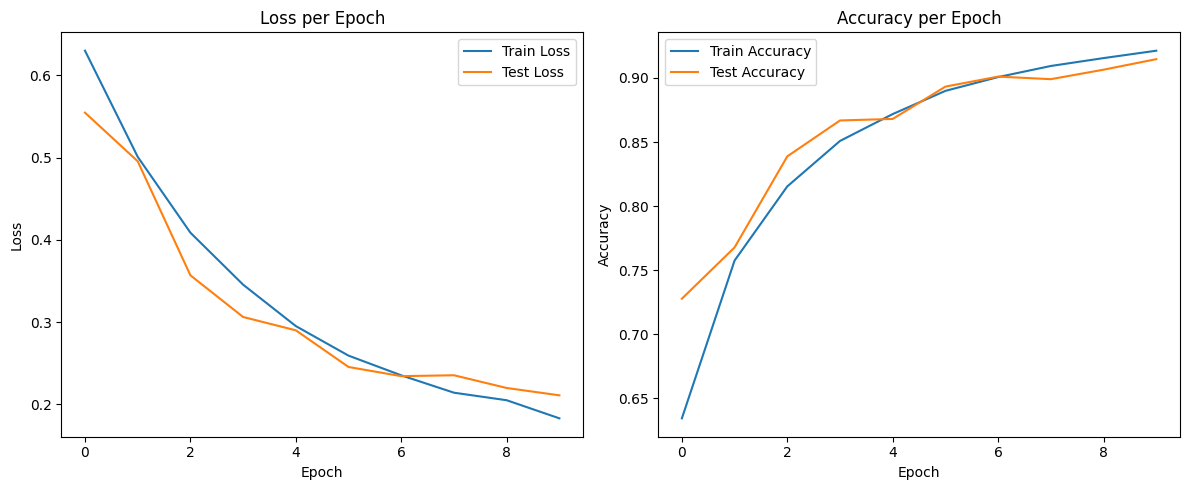

In [17]:



plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Test Accuracy')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [18]:
class ModifiedAlexNet(nn.Module):
    def __init__(self, num_classes=2):
        super(ModifiedAlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Additional layers
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(64 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), 64 * 6 * 6)
        x = self.classifier(x)
        return x


In [19]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model setup
model = ModifiedAlexNet(num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
num_epochs = 10

# Tracking metrics
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []


# Training + Evaluation

for epoch in range(num_epochs):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    train_losses.append(total_loss / len(train_loader))
    train_accuracies.append(train_acc)

    # Evaluation
    model.eval()
    test_loss, correct, total = 0.0, 0, 0
    epoch_preds, epoch_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            if epoch == num_epochs - 1:
                epoch_preds.extend(preds.cpu().numpy())
                epoch_labels.extend(labels.cpu().numpy())

    test_acc = correct / total
    test_losses.append(test_loss / len(test_loader))
    test_accuracies.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_losses[-1]:.4f}, Test Acc: {test_acc:.4f}")


# Classification Report

print("\nClassification Report on Final Epoch:")
print(classification_report(epoch_labels, epoch_preds, target_names=class_names))



/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [1/10] | Train Loss: 0.6505, Train Acc: 0.6072 | Test Loss: 0.6283, Test Acc: 0.6244


/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [2/10] | Train Loss: 0.5463, Train Acc: 0.7230 | Test Loss: 0.4795, Test Acc: 0.7616


/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


...

Epoch [8/10] | Train Loss: 0.2288, Train Acc: 0.9049 | Test Loss: 0.2229, Test Acc: 0.9070


/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [9/10] | Train Loss: 0.2122, Train Acc: 0.9124 | Test Loss: 0.2349, Test Acc: 0.9038


/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [10/10] | Train Loss: 0.1964, Train Acc: 0.9191 | Test Loss: 0.2540, Test Acc: 0.9036

Classification Report on Final Epoch:
              precision    recall  f1-score   support

         cat       0.86      0.96      0.91      2500
         dog       0.95      0.85      0.90      2500

    accuracy                           0.90      5000
   macro avg       0.91      0.90      0.90      5000
weighted avg       0.91      0.90      0.90      5000



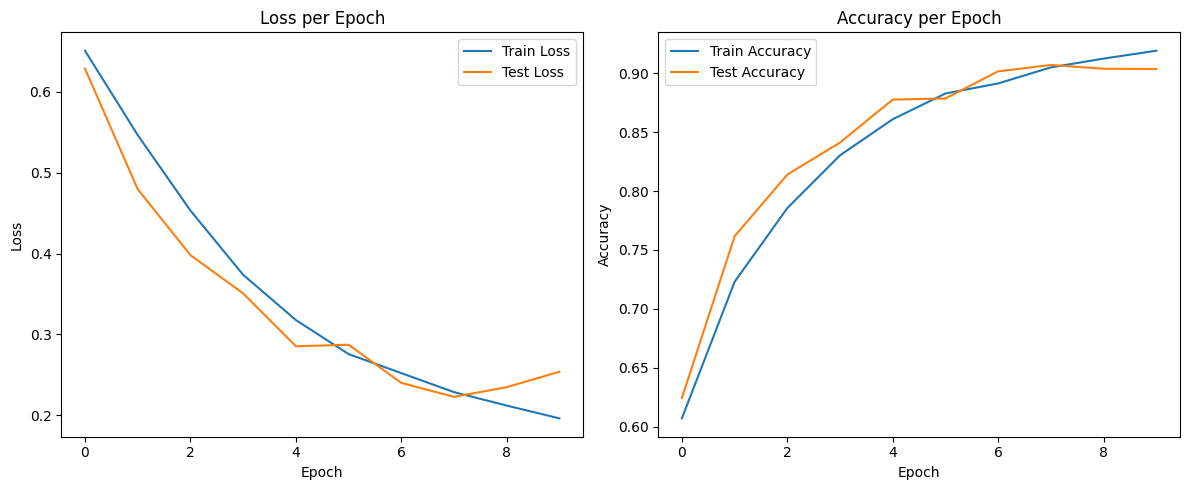

In [20]:


# Plotting

plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.title("Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [21]:

from torchvision import transforms, datasets, models
from torch import nn, optim

# Define a custom neural network that uses ResNet18 as a feature extractor
class ResNetFeatureExtractor(nn.Module):
    def __init__(self, num_classes=2):
        super(ResNetFeatureExtractor, self).__init__()

        # Load a pretrained ResNet-18 model
        base = models.resnet18(pretrained=True)

        # Freeze all the layers in the pretrained model so their weights won't update during training
        for param in base.parameters():
            param.requires_grad = False

        # Remove the last fully connected layer (fc) from ResNet18
        self.base = nn.Sequential(*list(base.children())[:-1])  # output size: (batch_size, 512, 1, 1)

        # Define a new classifier layer to adapt the extracted features to our specific task
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        # Pass input through the ResNet18 feature extractor
        x = self.base(x)  # Output shape: (batch_size, 512, 1, 1)

        # Flatten the tensor from 4D (batch_size, 512, 1, 1) to 2D (batch_size, 512)
        x = x.view(x.size(0), -1)

        # Pass the flattened features through the custom classifier
        return self.classifier(x)


In [22]:
# Initialize model
model = ResNetFeatureExtractor(num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.0001)
num_epochs = 10

# Tracking metrics
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []


# Training + Evaluation

for epoch in range(num_epochs):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    train_losses.append(total_loss / len(train_loader))
    train_accuracies.append(train_acc)

    # Evaluation
    model.eval()
    test_loss, correct, total = 0.0, 0, 0
    epoch_preds, epoch_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            if epoch == num_epochs - 1:
                epoch_preds.extend(preds.cpu().numpy())
                epoch_labels.extend(labels.cpu().numpy())

    test_acc = correct / total
    test_losses.append(test_loss / len(test_loader))
    test_accuracies.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_losses[-1]:.4f}, Test Acc: {test_acc:.4f}")


# Classification Report

print("\nClassification Report on Final Epoch:")
print(classification_report(epoch_labels, epoch_preds, target_names=class_names))



/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 153MB/s]
/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [1/10] | Train Loss: 0.3313, Train Acc: 0.8877 | Test Loss: 0.1685, Test Acc: 0.9602


/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [2/10] | Train Loss: 0.1662, Train Acc: 0.9494 | Test Loss: 0.1207, Test Acc: 0.9650


/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


...

Epoch [8/10] | Train Loss: 0.1017, Train Acc: 0.9621 | Test Loss: 0.0749, Test Acc: 0.9732


/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [9/10] | Train Loss: 0.0983, Train Acc: 0.9637 | Test Loss: 0.0691, Test Acc: 0.9744


/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [10/10] | Train Loss: 0.1000, Train Acc: 0.9618 | Test Loss: 0.0671, Test Acc: 0.9752

Classification Report on Final Epoch:
              precision    recall  f1-score   support

         cat       0.97      0.98      0.98      2500
         dog       0.98      0.97      0.98      2500

    accuracy                           0.98      5000
   macro avg       0.98      0.98      0.98      5000
weighted avg       0.98      0.98      0.98      5000



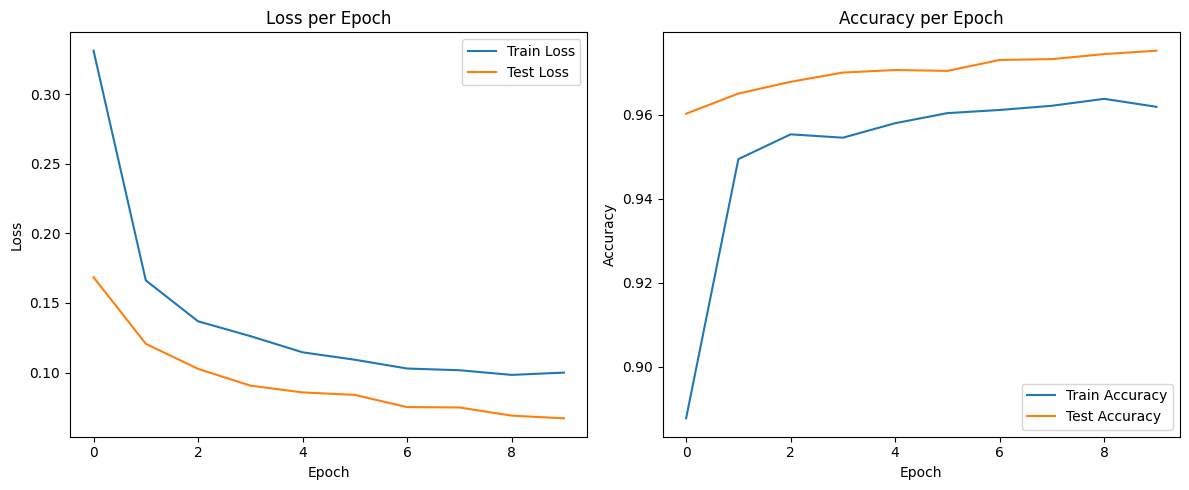

In [23]:
# ============================
# Plotting
# ============================
plt.figure(figsize=(8, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.title("Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## summary

| Model                | Final Test Accuracy | Final Test Loss | F1-Score (Cat/Dog)                    | Best for                    |
| -------------------- | ------------------- | --------------- | ------------------------------------- | --------------------------- |
| **AlexNet**          | 91.46%              | 0.2109          | 0.92 / 0.91                           | Balanced performance        |
| **Modified AlexNet** | 90.36%              | 0.2540          | 0.91 / 0.90                           | Simpler, similar to AlexNet |
| **ResNet18**         | **97.32%**          | **0.0671**      | 0.98 / 0.98|  **Best performing**      |

---

| Feature           | AlexNet        | Modified AlexNet | ResNet18 (Pretrained)          |
| ----------------- | -------------- | ---------------- | ------------------------------ |
| Depth             | Shallow CNN    | Slightly deeper  | Deep Residual Network          |
| Transfer Learning |  No           |  No             |  Yes (ImageNet pretrained)    |
| Performance       | Good           | Moderate–Good    |  Excellent                   |
| Training Time     | Short–Moderate | Short–Moderate   | Longer (with initial download) |
